# Imports + Project Paths + Device

In [1]:
import csv
import os
import sys
import json
import time
from decimal import Decimal
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)

try:
    import seaborn as sns
    _HAS_SNS = True
except Exception:
    _HAS_SNS = False

try:
    from IPython.display import display
except Exception:
    display = None


def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start] + list(start.parents):
        if (p / "data" / "split").exists() or (p / "data" / "raw").exists():
            return p
    raise FileNotFoundError(
        "Project root tidak ditemukan. Jalankan notebook dari dalam folder proyek."
    )


PROJECT_ROOT = find_project_root(Path.cwd())

DATA_DIR = (PROJECT_ROOT / "data" / "split").resolve()
MODEL_DIR = (PROJECT_ROOT / "models").resolve()

REPORT_EVAL_DIR = (PROJECT_ROOT / "results" / "reports" / "evaluation").resolve()
FIGURE_EVAL_DIR = (PROJECT_ROOT / "results" / "figures" / "evaluation").resolve()

REPORT_EVAL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_EVAL_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    device = torch.device("cuda")
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_DIR     : {DATA_DIR}")
print(f"MODEL_DIR    : {MODEL_DIR}")
print(f"REPORT_EVAL  : {REPORT_EVAL_DIR}")
print(f"FIGURE_EVAL  : {FIGURE_EVAL_DIR}")
print(f"DEVICE       : {device}")

PROJECT_ROOT : C:\Users\dwork\Downloads\Garbage_Classification_Thesis
DATA_DIR     : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\data\split
MODEL_DIR    : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\models
REPORT_EVAL  : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\evaluation
FIGURE_EVAL  : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\figures\evaluation
DEVICE       : cuda


# Config

In [2]:
TARGET_MODEL_NAME = "convnext_tiny_finetuned"
BATCH_SIZE = 32

CKPT_PATH = (MODEL_DIR / TARGET_MODEL_NAME / "best_model.pth").resolve()

TRAINING_SUMMARY_PATH = (
    PROJECT_ROOT
    / "results"
    / "reports"
    / "training"
    / TARGET_MODEL_NAME
    / "training_summary.json"
).resolve()

EVAL_SUMMARY_CSV_PATH = (REPORT_EVAL_DIR / "evaluation_summary.csv").resolve()
CLASSIF_REPORT_CSV_PATH = (REPORT_EVAL_DIR / f"classification_report_{TARGET_MODEL_NAME}.csv").resolve()
CM_FIG_PATH = (FIGURE_EVAL_DIR / f"confusion_matrix_{TARGET_MODEL_NAME}.png").resolve()

print("CONFIG")
print(f"- TARGET_MODEL_NAME       : {TARGET_MODEL_NAME}")
print(f"- CKPT_PATH               : {CKPT_PATH}")
print(f"- TRAINING_SUMMARY_PATH   : {TRAINING_SUMMARY_PATH}")
print(f"- EVAL_SUMMARY_CSV_PATH   : {EVAL_SUMMARY_CSV_PATH}")
print(f"- CLASSIF_REPORT_CSV_PATH : {CLASSIF_REPORT_CSV_PATH}")
print(f"- CM_FIG_PATH             : {CM_FIG_PATH}")

CONFIG
- TARGET_MODEL_NAME       : convnext_tiny_finetuned
- CKPT_PATH               : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\models\convnext_tiny_finetuned\best_model.pth
- TRAINING_SUMMARY_PATH   : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\training\convnext_tiny_finetuned\training_summary.json
- EVAL_SUMMARY_CSV_PATH   : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\evaluation\evaluation_summary.csv
- CLASSIF_REPORT_CSV_PATH : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\evaluation\classification_report_convnext_tiny_finetuned.csv
- CM_FIG_PATH             : C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\figures\evaluation\confusion_matrix_convnext_tiny_finetuned.png


# Load Test Dataset + DataLoader

In [3]:
TEST_DIR = (DATA_DIR / "test").resolve()
if not TEST_DIR.exists():
    raise FileNotFoundError(f"Folder test tidak ditemukan: {TEST_DIR}")

test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

test_dataset = datasets.ImageFolder(root=str(TEST_DIR), transform=test_transforms)
if len(test_dataset) == 0:
    raise ValueError(f"Dataset test kosong. Cek isi: {TEST_DIR}")

num_workers = 2
if os.name == "nt":
    num_workers = 0
if sys.platform == "darwin":
    num_workers = 0

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)

test_class_names = list(test_dataset.classes)
test_num_classes = len(test_class_names)

print("TEST DATASET")
print(f"- Samples     : {len(test_dataset)}")
print(f"- Num classes : {test_num_classes}")
print(f"- Classes     : {test_class_names}")

TEST DATASET
- Samples     : 2328
- Num classes : 12
- Classes     : ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


# Load Training Summary

In [4]:
def load_json_decimal(path: Path) -> dict:
    path = Path(path)
    if not path.exists():
        return {}
    text = path.read_text(encoding="utf-8")
    return json.loads(text, parse_float=Decimal)

def num_to_str_exact(x) -> str:
    if x is None:
        return ""
    if isinstance(x, Decimal):
        return str(x)
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    try:
        if isinstance(x, (float, np.floating)) and np.isnan(x):
            return ""
    except Exception:
        pass
    return str(Decimal(str(x)))

train_summary = load_json_decimal(TRAINING_SUMMARY_PATH)

final_train_acc_dec = train_summary.get("final_train_acc", Decimal("0"))
final_val_acc_dec   = train_summary.get("final_val_acc", Decimal("0"))
best_val_acc_dec    = train_summary.get("best_val_acc", Decimal("0"))
best_epoch_int      = int(train_summary.get("best_epoch", -1))
total_epochs_int    = int(train_summary.get("total_epochs", 0))
total_time_sec_dec  = train_summary.get("total_training_time_sec", Decimal("0"))

final_train_acc_s = num_to_str_exact(final_train_acc_dec)
final_val_acc_s   = num_to_str_exact(final_val_acc_dec)
best_val_acc_s    = num_to_str_exact(best_val_acc_dec)
best_epoch_s      = num_to_str_exact(best_epoch_int)
total_epochs_s    = num_to_str_exact(total_epochs_int)
total_time_sec_s  = num_to_str_exact(total_time_sec_dec)

if train_summary:
    print("TRAINING SUMMARY (exact)")
    print("- final_train_acc:", final_train_acc_s)
    print("- final_val_acc  :", final_val_acc_s)
    print("- best_val_acc   :", best_val_acc_s)
    print("- best_epoch     :", best_epoch_s)
    print("- total_epochs   :", total_epochs_s)
    print("- total_time_sec :", total_time_sec_s)
else:
    print("training_summary.json tidak ditemukan / kosong. Semua nilai default 0.")

TRAINING SUMMARY (exact)
- final_train_acc: 0.9972375690607734
- final_val_acc  : 0.9845294370434036
- best_val_acc   : 0.9853889127632144
- best_epoch     : 17
- total_epochs   : 25
- total_time_sec : 1976.3344695568085


# Model Utils

In [5]:
def _load_convnext(base_arch: str):
    name = base_arch.lower().strip()
    if name == "convnext_tiny":
        return models.convnext_tiny(weights=None)
    if name == "convnext_small":
        return models.convnext_small(weights=None)
    if name == "convnext_base":
        return models.convnext_base(weights=None)
    if name == "convnext_large":
        return models.convnext_large(weights=None)
    raise ValueError(f"Arsitektur '{base_arch}' tidak dikenali.")


def replace_last_linear(module: nn.Module, out_features: int) -> int:
    last_linear = None
    last_parent = None
    last_name = None

    for parent in module.modules():
        for name, child in parent.named_children():
            if isinstance(child, nn.Linear):
                last_linear = child
                last_parent = parent
                last_name = name

    if last_linear is None:
        raise RuntimeError("Tidak menemukan nn.Linear untuk diganti pada classifier.")

    in_features = last_linear.in_features
    setattr(last_parent, last_name, nn.Linear(in_features, out_features))
    return in_features


def strip_module_prefix(state_dict: dict) -> dict:
    if not isinstance(state_dict, dict):
        return state_dict
    keys = list(state_dict.keys())
    if not keys:
        return state_dict
    if all(k.startswith("module.") for k in keys):
        return {k.replace("module.", "", 1): v for k, v in state_dict.items()}
    return state_dict


def load_checkpoint_any_format(ckpt_path: Path, map_location) -> dict:
    ckpt_path = Path(ckpt_path)
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint tidak ditemukan: {ckpt_path}")

    obj = torch.load(ckpt_path, map_location=map_location)

    if not isinstance(obj, dict):
        raise RuntimeError("Format checkpoint tidak didukung (bukan dict).")

    if "model_state_dict" in obj and isinstance(obj["model_state_dict"], dict):
        sd = obj["model_state_dict"]
        meta = obj
    elif "state_dict" in obj and isinstance(obj["state_dict"], dict):
        sd = obj["state_dict"]
        meta = obj
    else:
        looks_like_sd = any("." in k for k in obj.keys())
        sd = obj if looks_like_sd else obj
        meta = {} if looks_like_sd else {}

    sd = strip_module_prefix(sd)
    return {"state_dict": sd, "meta": meta}


def infer_base_arch(model_name: str) -> str:
    return model_name.replace("_finetuned", "").strip()

# Build Model + Load Checkpoint + Validate Classes

In [6]:
BASE_ARCH = infer_base_arch(TARGET_MODEL_NAME)

ckpt_bundle = load_checkpoint_any_format(CKPT_PATH, map_location=device)
state_dict = ckpt_bundle["state_dict"]
ckpt_meta = ckpt_bundle["meta"]

ckpt_class_names = ckpt_meta.get("class_names", None)
ckpt_num_classes = len(ckpt_class_names) if isinstance(ckpt_class_names, list) else None

if ckpt_num_classes is not None and ckpt_num_classes != test_num_classes:
    raise ValueError(
        "Mismatch jumlah kelas antara checkpoint dan test dataset.\n"
        f"- ckpt_num_classes : {ckpt_num_classes}\n"
        f"- test_num_classes : {test_num_classes}\n"
        "Fix: samakan struktur folder kelas di data/split/* dengan saat training."
    )

report_class_names = ckpt_class_names if isinstance(ckpt_class_names, list) else test_class_names
report_num_classes = len(report_class_names)

if isinstance(ckpt_class_names, list):
    if set(ckpt_class_names) != set(test_class_names):
        raise ValueError(
            "Set nama kelas checkpoint != set nama kelas test.\n"
            f"- ckpt classes: {ckpt_class_names}\n"
            f"- test classes: {test_class_names}\n"
        )
    needs_remap_true = (ckpt_class_names != test_class_names)
else:
    needs_remap_true = False

if needs_remap_true:
    test_idx_to_name = {i: n for i, n in enumerate(test_class_names)}
    train_name_to_idx = {n: i for i, n in enumerate(ckpt_class_names)}

    def remap_y_true_from_test_to_train(y_true_test: np.ndarray) -> np.ndarray:
        return np.array([train_name_to_idx[test_idx_to_name[int(i)]] for i in y_true_test], dtype=int)

    print("urutan class test != training → y_true akan di-remap ke urutan training.")
else:
    def remap_y_true_from_test_to_train(y_true_test: np.ndarray) -> np.ndarray:
        return y_true_test

model = _load_convnext(BASE_ARCH)
if not hasattr(model, "classifier"):
    raise RuntimeError("Model ConvNeXt tidak punya attribute `.classifier` seperti yang diharapkan.")

_ = replace_last_linear(model.classifier, out_features=report_num_classes)
model = model.to(device)

missing, unexpected = model.load_state_dict(state_dict, strict=False)

print("Model loaded")
print(f"- Base arch          : {BASE_ARCH}")
print(f"- Output classes     : {report_num_classes}")
print(f"- Report class names : {report_class_names}")

if missing:
    print("\nMissing keys (first 20):", missing[:20], "..." if len(missing) > 20 else "")
if unexpected:
    print("\nUnexpected keys (first 20):", unexpected[:20], "..." if len(unexpected) > 20 else "")

Model loaded
- Base arch          : convnext_tiny
- Output classes     : 12
- Report class names : ['battery', 'biological', 'brown-glass', 'cardboard', 'clothes', 'green-glass', 'metal', 'paper', 'plastic', 'shoes', 'trash', 'white-glass']


# Predict on Test

In [7]:
@torch.no_grad()
def predict(model: nn.Module, dataloader: DataLoader, device: torch.device):
    model.eval()
    y_true, y_pred = [], []

    for inputs, labels in dataloader:
        inputs = inputs.to(device, non_blocking=(device.type == "cuda"))
        labels = labels.to(device, non_blocking=(device.type == "cuda"))

        logits = model(inputs)
        preds = torch.argmax(logits, dim=1)

        y_true.append(labels.detach().cpu().numpy())
        y_pred.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(y_true, axis=0)
    y_pred = np.concatenate(y_pred, axis=0)
    return y_true, y_pred


t0 = time.time()
y_true_test, y_pred_trainorder = predict(model, test_loader, device=device)
y_true_trainorder = remap_y_true_from_test_to_train(y_true_test)

print("Prediksi selesai")
print(f"- Num samples: {len(y_true_trainorder)}")
print(f"- Time (sec) : {time.time() - t0:.2f}")

Prediksi selesai
- Num samples: 2328
- Time (sec) : 6.61


# Compute Metric

In [8]:
test_acc = accuracy_score(y_true_trainorder, y_pred_trainorder)
precision_m, recall_m, f1_m, _ = precision_recall_fscore_support(
    y_true_trainorder,
    y_pred_trainorder,
    average="macro",
    zero_division=0,
)

test_acc_s    = num_to_str_exact(test_acc)
precision_m_s = num_to_str_exact(precision_m)
recall_m_s    = num_to_str_exact(recall_m)
f1_m_s        = num_to_str_exact(f1_m)

print("TEST RESULTS (exact)")
print("- test_acc        :", test_acc_s)
print("- precision_macro :", precision_m_s)
print("- recall_macro    :", recall_m_s)
print("- f1_macro        :", f1_m_s)

TEST RESULTS (exact)
- test_acc        : 0.9776632302405498
- precision_macro : 0.9749625670151575
- recall_macro    : 0.9751079267414049
- f1_macro        : 0.9748904446433087


# Confusion Matrix

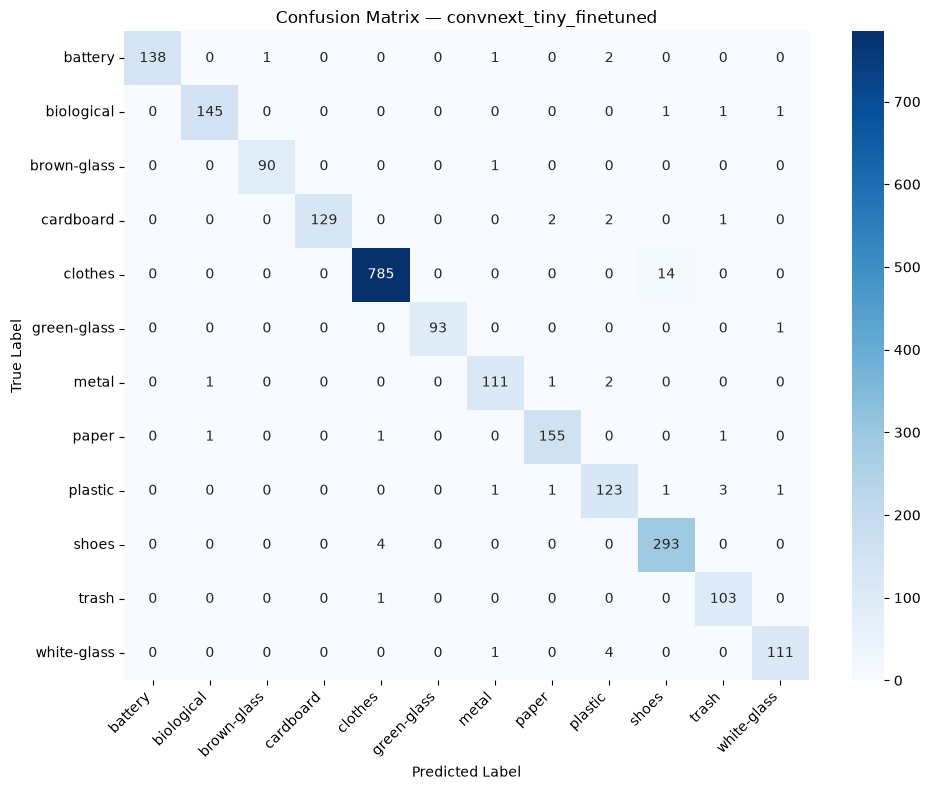

Confusion matrix tersimpan: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\figures\evaluation\confusion_matrix_convnext_tiny_finetuned.png


In [9]:
cm = confusion_matrix(
    y_true_trainorder,
    y_pred_trainorder,
    labels=list(range(report_num_classes))
)

plt.figure(figsize=(10, 8))
if _HAS_SNS:
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=report_class_names,
        yticklabels=report_class_names,
    )
else:
    plt.imshow(cm, interpolation="nearest")
    plt.colorbar()
    tick_marks = np.arange(report_num_classes)
    plt.xticks(tick_marks, report_class_names, rotation=45, ha="right")
    plt.yticks(tick_marks, report_class_names)
    for i in range(report_num_classes):
        for j in range(report_num_classes):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title(f"Confusion Matrix — {TARGET_MODEL_NAME}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(CM_FIG_PATH, dpi=300, bbox_inches="tight")
plt.show()

print(f"Confusion matrix tersimpan: {CM_FIG_PATH}")

# Classification Report

In [10]:
report_dict = classification_report(
    y_true_trainorder,
    y_pred_trainorder,
    target_names=report_class_names,
    output_dict=True,
    zero_division=0,
)

df_report = pd.DataFrame(report_dict).T.reset_index().rename(columns={"index": "class_label"})

preferred_cols = ["class_label", "precision", "recall", "f1-score", "support"]
existing_cols = [c for c in preferred_cols if c in df_report.columns]
other_cols = [c for c in df_report.columns if c not in existing_cols]
df_report = df_report[existing_cols + other_cols]

df_report_str = df_report.copy()
for col in df_report_str.columns:
    if col != "class_label":
        df_report_str[col] = df_report_str[col].map(num_to_str_exact)

df_report_str.to_csv(CLASSIF_REPORT_CSV_PATH, index=False)
print("classification_report CSV tersimpan (clean):", str(CLASSIF_REPORT_CSV_PATH))

if display is not None:
    display(df_report_str)
else:
    print(df_report_str.to_string(index=False))

classification_report CSV tersimpan (clean): C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\evaluation\classification_report_convnext_tiny_finetuned.csv


,class_label,precision,recall,f1-score,support
0,battery,1.0,0.971830985915493,0.9857142857142858,142.0
1,biological,0.9863945578231292,0.9797297297297297,0.9830508474576272,148.0
2,brown-glass,0.989010989010989,0.989010989010989,0.989010989010989,91.0
3,cardboard,1.0,0.9626865671641791,0.9809885931558935,134.0
4,clothes,0.9924146649810367,0.9824780976220275,0.9874213836477987,799.0
5,green-glass,1.0,0.9893617021276596,0.9946524064171123,94.0
6,metal,0.9652173913043478,0.9652173913043478,0.9652173913043478,115.0
7,paper,0.9748427672955975,0.9810126582278481,0.9779179810725552,158.0
8,plastic,0.924812030075188,0.9461538461538461,0.935361216730038,130.0
9,shoes,0.948220064724919,0.9865319865319865,0.966996699669967,297.0


# Append Evaluation Summary

In [11]:
row_str = {
    "model_name":           TARGET_MODEL_NAME,
    "base_arch":            BASE_ARCH,
    "num_classes":          num_to_str_exact(report_num_classes),
    "train_acc_final":      final_train_acc_s,
    "val_acc_best":         best_val_acc_s,
    "best_epoch":           best_epoch_s,
    "total_epochs":         total_epochs_s,
    "test_acc":             test_acc_s,
    "precision_macro":      precision_m_s,
    "recall_macro":         recall_m_s,
    "f1_macro":             f1_m_s,
    "checkpoint_path":      str(CKPT_PATH),
    "training_summary_path": str(TRAINING_SUMMARY_PATH),
}

cols = [
    "model_name",
    "base_arch",
    "num_classes",
    "train_acc_final",
    "val_acc_best",
    "best_epoch",
    "total_epochs",
    "test_acc",
    "precision_macro",
    "recall_macro",
    "f1_macro",
    "checkpoint_path",
    "training_summary_path",
]

file_exists = EVAL_SUMMARY_CSV_PATH.exists()
with open(EVAL_SUMMARY_CSV_PATH, "a", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=cols)
    if not file_exists:
        writer.writeheader()
    writer.writerow(row_str)

print("evaluation_summary.csv tersimpan/terupdate:", str(EVAL_SUMMARY_CSV_PATH))
print("Row yang ditulis (exact):")
for k in cols:
    print(f"- {k}: {row_str[k]}")

evaluation_summary.csv tersimpan/terupdate: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\evaluation\evaluation_summary.csv
Row yang ditulis (exact):
- model_name: convnext_tiny_finetuned
- base_arch: convnext_tiny
- num_classes: 12
- train_acc_final: 0.9972375690607734
- val_acc_best: 0.9853889127632144
- best_epoch: 17
- total_epochs: 25
- test_acc: 0.9776632302405498
- precision_macro: 0.9749625670151575
- recall_macro: 0.9751079267414049
- f1_macro: 0.9748904446433087
- checkpoint_path: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\models\convnext_tiny_finetuned\best_model.pth
- training_summary_path: C:\Users\dwork\Downloads\Garbage_Classification_Thesis\results\reports\training\convnext_tiny_finetuned\training_summary.json


# Show Latest Summary

In [12]:
try:
    df_all_str = pd.read_csv(EVAL_SUMMARY_CSV_PATH, dtype=str)
    print("Rekap evaluation_summary.csv (tail, exact text):")
    if display is not None:
        display(df_all_str.tail(10))
    else:
        print(df_all_str.tail(10).to_string(index=False))
except Exception as e:
    print("Gagal membaca/tampilkan evaluation_summary.csv:", e)

print("Done.")

Rekap evaluation_summary.csv (tail, exact text):


,model_name,base_arch,num_classes,train_acc_final,val_acc_best,best_epoch,total_epochs,test_acc,precision_macro,recall_macro,f1_macro,checkpoint_path,training_summary_path
0,convnext_tiny_finetuned,convnext_tiny,12,0.9972375690607734,0.9853889127632144,17,25,0.9776632302405498,0.9749625670151575,0.9751079267414049,0.9748904446433087,C:\Users\dwork\Downloads\Garbage_Classificatio...,C:\Users\dwork\Downloads\Garbage_Classificatio...


Done.
